In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("athiramolps/ice-cream-sales-and-temperature")

print("Path to dataset files:", path)

100%|██████████| 530/530 [00:00<00:00, 681kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/athiramolps/ice-cream-sales-and-temperature/versions/1


In [3]:
import pandas as pd

In [4]:
import os

# List files in the downloaded dataset path to find the CSV
file_list = os.listdir(path)
csv_files = [f for f in file_list if f.endswith('.csv')]

if csv_files:
    csv_file_name = csv_files[0] # Assuming there's one CSV file or we take the first one
    csv_file_path = os.path.join(path, csv_file_name)

    # Read the CSV into a pandas DataFrame
    df = pd.read_csv(csv_file_path)
    print(f"Successfully loaded '{csv_file_name}' into a DataFrame.")
    print("DataFrame head:")
    print(df.head())
else:
    print("No CSV files found in the dataset directory.")

Successfully loaded 'Ice Cream Sales and Temperature.csv' into a DataFrame.
DataFrame head:
         Date   Time  Temperature (Celsius)  Ice Cream Sales
0  2023-01-01  08:00                     18               20
1  2023-01-01  08:05                     19               22
2  2023-01-01  08:10                     20               25
3  2023-01-01  08:15                     21               24
4  2023-01-01  08:20                     22               26


In [5]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Define the independent variable (X) and dependent variable (y)
X = df[['Temperature (Celsius)']]
y = df['Ice Cream Sales']

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Get the coefficient
coefficient = model.coef_[0]

print(f"Coefficient for Temperature (Celsius) on Ice Cream Sales: {coefficient:.2f}")

Coefficient for Temperature (Celsius) on Ice Cream Sales: -0.71


This coefficient indicates how much 'Ice Cream Sales' are expected to change for every one-unit increase in 'Temperature (Celsius)', assuming a linear relationship.

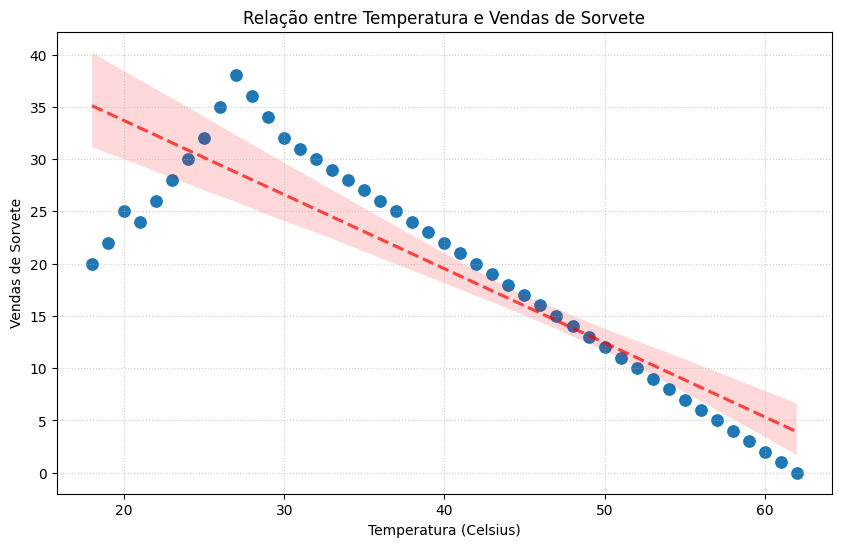

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature (Celsius)', y='Ice Cream Sales', data=df, s=100)
sns.regplot(x='Temperature (Celsius)', y='Ice Cream Sales', data=df, scatter=False, color='red', line_kws={'linestyle':'--', 'alpha':0.7})
plt.title('Relação entre Temperatura e Vendas de Sorvete')
plt.xlabel('Temperatura (Celsius)')
plt.ylabel('Vendas de Sorvete')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()